## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../Modules")
sys.path.insert(0, "../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x00000162CD889950> [0]

In [3]:
NUTS0 = 'GR'

In [4]:
timeline_file = pd.read_csv(f'../data/{NUTS0}_Timeline_GRID_2009-2022_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)


In [5]:
timeline_file.head()

,Unnamed: 0,x,y,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan
0,0,19.656538,39.718959,HL24,2009-01-01,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.707780,1,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,6.707780,6.707780,6.707780,6.707780
1,1,19.656538,39.718959,HL24,2009-01-02,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.564106,2,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,16.271885,16.271885,16.271885,16.271885
2,2,19.656538,39.718959,HL24,2009-01-03,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.859431,3,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,91.131317,91.131317,91.131317,91.131317
3,3,19.656538,39.718959,HL24,2009-01-04,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.159674,4,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,105.290990,105.290990,105.290990,105.290990
4,4,19.656538,39.718959,HL24,2009-01-05,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,14298.150000,13779.687500,14370.000000,13839.892857,14353.903226,14010.225806,14543.400000,14226.400000,105.290990,105.290990,105.290990,105.290990


In [6]:
timeline_file.shape

(22522765, 44)

In [7]:
wnv_file.head()

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0


In [8]:
wnv_file.shape

(52876, 3)

In [9]:
timeline_file.drop(columns=['Unnamed: 0'], inplace=True)

In [10]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [11]:
timeline_file.head()

,x,y,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan
0,19.656538,39.718959,HL24,2009-01-01,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.707780,1,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,6.707780,6.707780,6.707780,6.707780
1,19.656538,39.718959,HL24,2009-01-02,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.564106,2,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,16.271885,16.271885,16.271885,16.271885
2,19.656538,39.718959,HL24,2009-01-03,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.859431,3,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,91.131317,91.131317,91.131317,91.131317
3,19.656538,39.718959,HL24,2009-01-04,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.159674,4,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,105.290990,105.290990,105.290990,105.290990
4,19.656538,39.718959,HL24,2009-01-05,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,105.290990,105.290990,105.290990,105.290990


In [12]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [13]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [14]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [15]:
timeline_file

,x,y,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,19.656538,39.718959,HL24,2009-01-01,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.707780,1,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,6.707780,6.707780,6.707780,6.707780,NaN,7.628375,8.948929,10.491290,14.548000,0.500000,0.866025
1,19.656538,39.718959,HL24,2009-01-02,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.564106,2,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,16.271885,16.271885,16.271885,16.271885,NaN,7.628375,8.948929,10.491290,14.548000,0.500000,0.866025
2,19.656538,39.718959,HL24,2009-01-03,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.859431,3,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,91.131317,91.131317,91.131317,91.131317,NaN,7.628375,8.948929,10.491290,14.548000,0.500000,0.866025
3,19.656538,39.718959,HL24,2009-01-04,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.159674,4,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,105.290990,105.290990,105.290990,105.290990,NaN,7.628375,8.948929,10.491290,14.548000,0.500000,0.866025
4,19.656538,39.718959,HL24,2009-01-05,EL6,κεντρικη ελλαδα,EL62,ιονια νησια,EL622,κερκυρας,4.000000,3.000000,1.000000,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,12.813000,2.443750,14.250000,3.647857,13.928065,7.054516,17.718000,11.378000,105.290990,105.290990,105.290990,105.290990,NaN,7.628375,8.948929,10.491290,14.548000,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22522760,27.860317,36.529297,VD742,2022-12-27,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,συμης,2.000000,2.000000,1.000000,2022,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.000000,1.000000
22522761,27.860317,36.529297,VD742,2022-12-28,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,συμης,2.000000,2.000000,1.000000,2022,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.000000,1.000000
22522762,27.860317,36.529297,VD742,2022-12-29,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,συμης,2.000000,2.000000,1.000000,2022,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.000000,1.000000
22522763,27.860317,36.529297,VD742,2022-12-30,EL4,"νησια αιγαιου, κρητη",EL42,νοτιο αιγαιο,EL421,συμης,2.000000,2.000000,1.000000,2022,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.000000,1.000000


In [16]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [17]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_code','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [18]:
grouped_by_month_mean

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,7.764194,11.289533,16.000000,13.385833,7.764194,11.985000,10.422857,15.888065,7.003548,21.939333,10.883333,69.675667,124.789480,198.837012,198.922431,10.811250,10.575013,11.203929,11.445806,16.411333,0.500000,0.866025
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,10.422857,14.562216,14.500000,13.385833,7.764194,11.985000,10.422857,15.888065,7.003548,21.939333,10.883333,101.711578,188.662202,342.750185,538.278193,11.203929,10.575013,11.203929,11.445806,16.411333,0.866025,0.500000
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,3.000000,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,7.003548,6.033606,16.000000,13.385833,7.764194,11.985000,10.422857,15.888065,7.003548,21.939333,10.883333,50.412024,123.981315,351.138909,884.408596,11.445806,10.575013,11.203929,11.445806,16.411333,1.000000,0.000000
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,4.000000,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,10.883333,4.573572,15.500000,13.385833,7.764194,11.985000,10.422857,15.888065,7.003548,21.939333,10.883333,32.448004,66.873231,162.180222,1050.388847,16.411333,10.575013,11.203929,11.445806,16.411333,0.866025,-0.500000
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,5.000000,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,27.500323,14.963548,2.087833,16.000000,13.385833,7.764194,11.985000,10.422857,15.888065,7.003548,21.939333,10.883333,15.471587,32.834753,76.663468,1128.070950,21.231935,10.575013,11.203929,11.445806,16.411333,0.500000,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715675,ZV382,2022-08,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,8.000000,0.395348,0.142966,-0.394125,-0.142966,0.416545,0.164676,-0.403058,-0.164676,0.048521,0.048869,0.033257,0.048869,32.791290,22.457097,0.974678,16.000000,12.654516,7.750645,14.750714,7.264286,15.870000,5.857097,20.195333,12.184000,1.601303,1.696395,1.696395,1034.896717,27.624194,10.202581,11.007500,10.863548,16.189667,-0.866025,-0.500000
715676,ZV382,2022-09,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,9.000000,0.439553,0.128380,-0.418841,-0.128380,0.452942,0.159895,-0.419358,-0.159895,0.049214,0.050873,0.030643,0.050873,30.084667,20.181333,0.800374,15.500000,12.654516,7.750645,14.750714,7.264286,15.870000,5.857097,20.195333,12.184000,10.898656,18.687968,34.802648,1069.755911,25.133000,10.202581,11.007500,10.863548,16.189667,-1.000000,-0.000000
715677,ZV3

In [19]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_code','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [20]:
grouped_by_month_dataset.head()

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,7.764194,10.811250,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,11.289533,89.988620,121.504665,347.327549,349.975530,10.370000,5.030000,15.310000,13.810000,349.975530
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,10.422857,11.203929,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,14.562216,133.844776,205.302734,422.839291,757.717577,7.350000,3.610000,18.390000,11.070000,407.742047
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,3.000000,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,7.003548,11.445806,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,6.033606,16.994903,36.774120,174.351656,944.759366,7.850000,3.610000,19.090000,10.710000,187.041788
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,4.000000,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,10.883333,16.411333,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,4.573572,12.160266,19.701893,137.207154,1081.966519,16.870000,8.150000,25.890000,14.510000,137.207154
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,5.000000,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,27.500323,14.963548,21.231935,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,2.087833,1.402261,21.129889,64.722820,1146.689339,20.470000,10.090000,34.950000,19.870000,64.722820


In [21]:
grouped_by_month_dataset

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,7.764194,10.811250,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,11.289533,89.988620,121.504665,347.327549,349.975530,10.370000,5.030000,15.310000,13.810000,349.975530
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,10.422857,11.203929,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,14.562216,133.844776,205.302734,422.839291,757.717577,7.350000,3.610000,18.390000,11.070000,407.742047
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,3.000000,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,7.003548,11.445806,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,6.033606,16.994903,36.774120,174.351656,944.759366,7.850000,3.610000,19.090000,10.710000,187.041788
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,4.000000,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,10.883333,16.411333,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,4.573572,12.160266,19.701893,137.207154,1081.966519,16.870000,8.150000,25.890000,14.510000,137.207154
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2.000000,2.000000,1.000000,2009.000000,5.000000,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,27.500323,14.963548,21.231935,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,2.087833,1.402261,21.129889,64.722820,1146.689339,20.470000,10.090000,34.950000,19.870000,64.722820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715675,ZV382,2022-08,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,8.000000,0.395348,0.142966,-0.394125,-0.142966,0.416545,0.164676,-0.403058,-0.164676,0.048521,0.048869,0.033257,0.048869,32.791290,22.457097,27.624194,12.654516,14.750714,15.870000,20.195333,7.750645,7.264286,5.857097,12.184000,10.202581,11.007500,10.863548,16.189667,0.974678,27.689264,30.215026,30.215026,1063.415348,27.830000,19.930000,38.230000,25.310000,30.215026
715676,ZV382,2022-09,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2.000000,2.000000,1.000000,2022.000000,9.000000,0.439553,0.128380,-0.418841,-0.128380,0.452942,0.159895,-0.419358,-0.159895,0.049214,0.050873,0.030643,0.050873,30.084667,20.181333,25.133000,12.654516,14

In [22]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [23]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [24]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [25]:
grouped_by_month_dataset

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,7.764194,10.811250,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,11.289533,89.988620,121.504665,347.327549,349.975530,349.975530,5.030000,15.310000
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,10.422857,11.203929,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,14.562216,133.844776,205.302734,422.839291,757.717577,407.742047,3.610000,18.390000
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,3,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,7.003548,11.445806,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,6.033606,16.994903,36.774120,174.351656,944.759366,187.041788,3.610000,19.090000
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,4,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,10.883333,16.411333,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,4.573572,12.160266,19.701893,137.207154,1081.966519,137.207154,8.150000,25.890000
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,5,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,27.500323,14.963548,21.231935,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,2.087833,1.402261,21.129889,64.722820,1146.689339,64.722820,10.090000,34.950000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715675,ZV382,2022-08,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2,2,1,2022,8,0.395348,0.142966,-0.394125,-0.142966,0.416545,0.164676,-0.403058,-0.164676,0.048521,0.048869,0.033257,0.048869,32.791290,22.457097,27.624194,12.654516,14.750714,15.870000,20.195333,7.750645,7.264286,5.857097,12.184000,10.202581,11.007500,10.863548,16.189667,0.974678,27.689264,30.215026,30.215026,1063.415348,30.215026,19.930000,38.230000
715676,ZV382,2022-09,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2,2,1,2022,9,0.439553,0.128380,-0.418841,-0.128380,0.452942,0.159895,-0.419358,-0.159895,0.049214,0.050873,0.030643,0.050873,30.084667,20.181333,25.133000,12.654516,14.750714,15.870000,20.195333,7.750645,7.264286,5.857097,12.184000,10.202581,11.007500,10.863548,16.189667,0.800374,1.285089,24.011210,24.011210,1087.426558,24.011210,14.330000,34.810000
715677,ZV382,2022-10,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,23.841896,35.491796,2,2,1,2022,10,0.376221,0.174545,-0.322338,-0.174545,0.403171,0.203393,-0.340343,-0.203393,0.052576,0.049655,0.050135,0.049655,25

### Add Geomorphological and Land Cover/Use

In [26]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [27]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [28]:
dataset_locations

,x,y
0,24.117404,35.410691
1,24.789225,35.408170
2,24.172455,35.401609
3,24.172455,35.401609
4,24.238531,35.401496
...,...,...
6801,23.731075,35.662913
6802,23.731075,35.662913
6803,23.731075,35.662913
6804,23.775445,35.599889


In [29]:
dataset_locations_per_year

,x,y,year
0,24.117404,35.410691,2009
1,24.117404,35.410691,2010
2,24.117404,35.410691,2011
3,24.117404,35.410691,2012
4,24.117404,35.410691,2013
...,...,...,...
83606,23.841896,35.491796,2018
83607,23.841896,35.491796,2019
83608,23.841896,35.491796,2020
83609,23.841896,35.491796,2021


In [31]:
geomorphological = pd.read_csv(f'../data/{NUTS0}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [32]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05


In [33]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_8096\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [34]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,24.117404,35.410691,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027
1,24.789225,35.408170,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711
2,24.172455,35.401609,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146
3,24.172455,35.401609,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146
4,24.238531,35.401496,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420
...,...,...,...,...,...,...,...,...,...,...
6801,23.731075,35.662913,1183.531557,14645.614548,18,57.899702,356.922449,167.979475,0.000000,1.031910
6802,23.731075,35.662913,1183.531557,14645.614548,18,57.899702,356.922449,167.979475,0.000000,1.031910
6803,23.731075,35.662913,1183.531557,14645.614548,18,57.899702,356.922449,167.979475,0.000000,1.031910
6804,23.775445,35.599889,118.338740,6812.653826,31,88.700429,79.875891,156.301418,1.279013,7.297534


In [35]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [36]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [37]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [38]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,24.117404,35.410691,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027
1,24.789225,35.408170,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711
2,24.172455,35.401609,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146
3,24.172455,35.401609,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146
4,24.238531,35.401496,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420
...,...,...,...,...,...,...,...,...,...,...
6801,23.731075,35.662913,1183.531557,14645.614548,18,57.899702,356.922449,167.979475,0.000000,1.031910
6802,23.731075,35.662913,1183.531557,14645.614548,18,57.899702,356.922449,167.979475,0.000000,1.031910
6803,23.731075,35.662913,1183.531557,14645.614548,18,57.899702,356.922449,167.979475,0.000000,1.031910
6804,23.775445,35.599889,118.338740,6812.653826,31,88.700429,79.875891,156.301418,1.279013,7.297534


In [39]:
landcover = pd.read_csv(f'../data/{NUTS0}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [40]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [41]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [42]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [43]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [44]:
landcover_2023 = landcover_2022

In [45]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2010
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2011
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2012
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2013
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2014
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2015
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2016
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2017
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2018
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2019
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year: 2020
Min distance: 6.110723994763106e-07
Max distance: 6.908690099065017e-05
Year

In [46]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [47]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,24.117404,35.410691,2009,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0
1,24.789225,35.408170,2009,31,86.000000,30,86.000000,50,61.000000,11,10,1,6,6,2,0
2,24.172455,35.401609,2009,31,90.000000,30,90.000000,30,90.000000,10,10,1,6,6,2,0
3,24.172455,35.401609,2009,31,90.000000,30,90.000000,30,90.000000,10,10,1,6,6,2,0
4,24.238531,35.401496,2009,21,67.000000,20,67.000000,20,67.000000,8,8,4,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83606,23.006578,36.173006,2022,22,90.000000,20,90.000000,20,90.000000,9,9,4,1,1,2,0
83607,23.731075,35.662913,2022,22,95.000000,20,95.000000,20,95.000000,9,9,4,1,1,2,0
83608,23.731075,35.662913,2022,22,95.000000,20,95.000000,20,95.000000,9,9,4,1,1,2,0
83609,23.775445,35.599889,2022,22,79.000000,20,79.000000,20,79.000000,9,9,4,1,1,2,0


In [48]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [49]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [50]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [51]:
bio_values_df = grouped_by_month_dataset[['cell_code','year','month','rainfall_acc','lst_min','lst_max']]

In [52]:
bio_values_df.head(15)

,cell_code,year,month,rainfall_acc,lst_min,lst_max
0,AAE407,2009,1,349.975530,5.030000,15.310000
1,AAE407,2009,2,407.742047,3.610000,18.390000
2,AAE407,2009,3,187.041788,3.610000,19.090000
3,AAE407,2009,4,137.207154,8.150000,25.890000
4,AAE407,2009,5,64.722820,10.090000,34.950000
5,AAE407,2009,6,6.922986,16.750000,39.070000
6,AAE407,2009,7,4.763591,19.290000,42.770000
7,AAE407,2009,8,5.629007,18.150000,40.470000
8,AAE407,2009,9,150.267353,14.710000,38.570000
9,AAE407,2009,10,342.137486,12.690000,30.670000


In [53]:
wnv_file.head(5)

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0


In [54]:
wnv_file

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0
...,...,...,...
52871,RN287,2021-06,0
52872,RN287,2021-07,0
52873,RN287,2021-08,0
52874,RN287,2021-09,0


In [55]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715680 entries, 0 to 715679
Data columns (total 71 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   cell_code            715680 non-null  object   
 1   dt_placement         715680 non-null  period[M]
 2   NUTS1_ID             715680 non-null  object   
 3   NUTS1_NAME           715680 non-null  object   
 4   NUTS2_ID             715680 non-null  object   
 5   NUTS2_NAME           715680 non-null  object   
 6   NUTS3_ID             715680 non-null  object   
 7   LAU1_NAME            715680 non-null  object   
 8   x                    715680 non-null  float64  
 9   y                    715680 non-null  float64  
 10  MOUNT_TYPE           715680 non-null  int32    
 11  URBN_TYPE            715680 non-null  int32    
 12  COAST_TYPE           715680 non-null  int32    
 13  year                 715680 non-null  int32    
 14  month                715680 non-null

In [56]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52876 entries, 0 to 52875
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cell_code     52876 non-null  object
 1   dt_placement  52876 non-null  object
 2   cases         52876 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [57]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [58]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52876 entries, 0 to 52875
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   cell_code     52876 non-null  object   
 1   dt_placement  52876 non-null  period[M]
 2   cases         52876 non-null  int64    
dtypes: int64(1), object(1), period[M](1)
memory usage: 1.2+ MB


In [59]:
wnv_file

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0
...,...,...,...
52871,RN287,2021-06,0
52872,RN287,2021-07,0
52873,RN287,2021-08,0
52874,RN287,2021-09,0


In [60]:
wnv_file['cases'].value_counts()

cases
0    51635
1     1135
2       83
3       17
4        4
6        2
Name: count, dtype: int64

In [61]:
wnv_file.cases.sum()

1380

In [62]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )

In [63]:
merged

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,cases
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,7.764194,10.811250,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,11.289533,89.988620,121.504665,347.327549,349.975530,349.975530,5.030000,15.310000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,NaN
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,10.422857,11.203929,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,14.562216,133.844776,205.302734,422.839291,757.717577,407.742047,3.610000,18.390000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,NaN
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,3,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,7.003548,11.445806,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,6.033606,16.994903,36.774120,174.351656,944.759366,187.041788,3.610000,19.090000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,NaN
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,4,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,10.883333,16.411333,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,4.573572,12.160266,19.701893,137.207154,1081.966519,137.207154,8.150000,25.890000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,NaN
4,AAE407,2009-05,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,5,0.471428,0.120528,-0.320907,-0.120528,0.460429,0.114496,-0.325489,-0.114496,0.015291,0.019054,0.010822,0.019054,27.500323,14.963548,21.231935,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,2.087833,1.402261,21.129889,64.722820,1146.689339,64.722820,10.090000,34.950000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715691,ZV382,2022-08,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,πλατανια,2

In [64]:
merged = fillna(merged,{'cases': 0})

In [65]:
merged['cases'].value_counts()

cases
0.000000    714455
1.000000      1135
2.000000        83
3.000000        17
4.000000         4
6.000000         2
Name: count, dtype: int64

In [66]:
merged.cases.sum()

1380.0

In [67]:
merged = merged.astype({'cases': 'int'})

<Axes: >

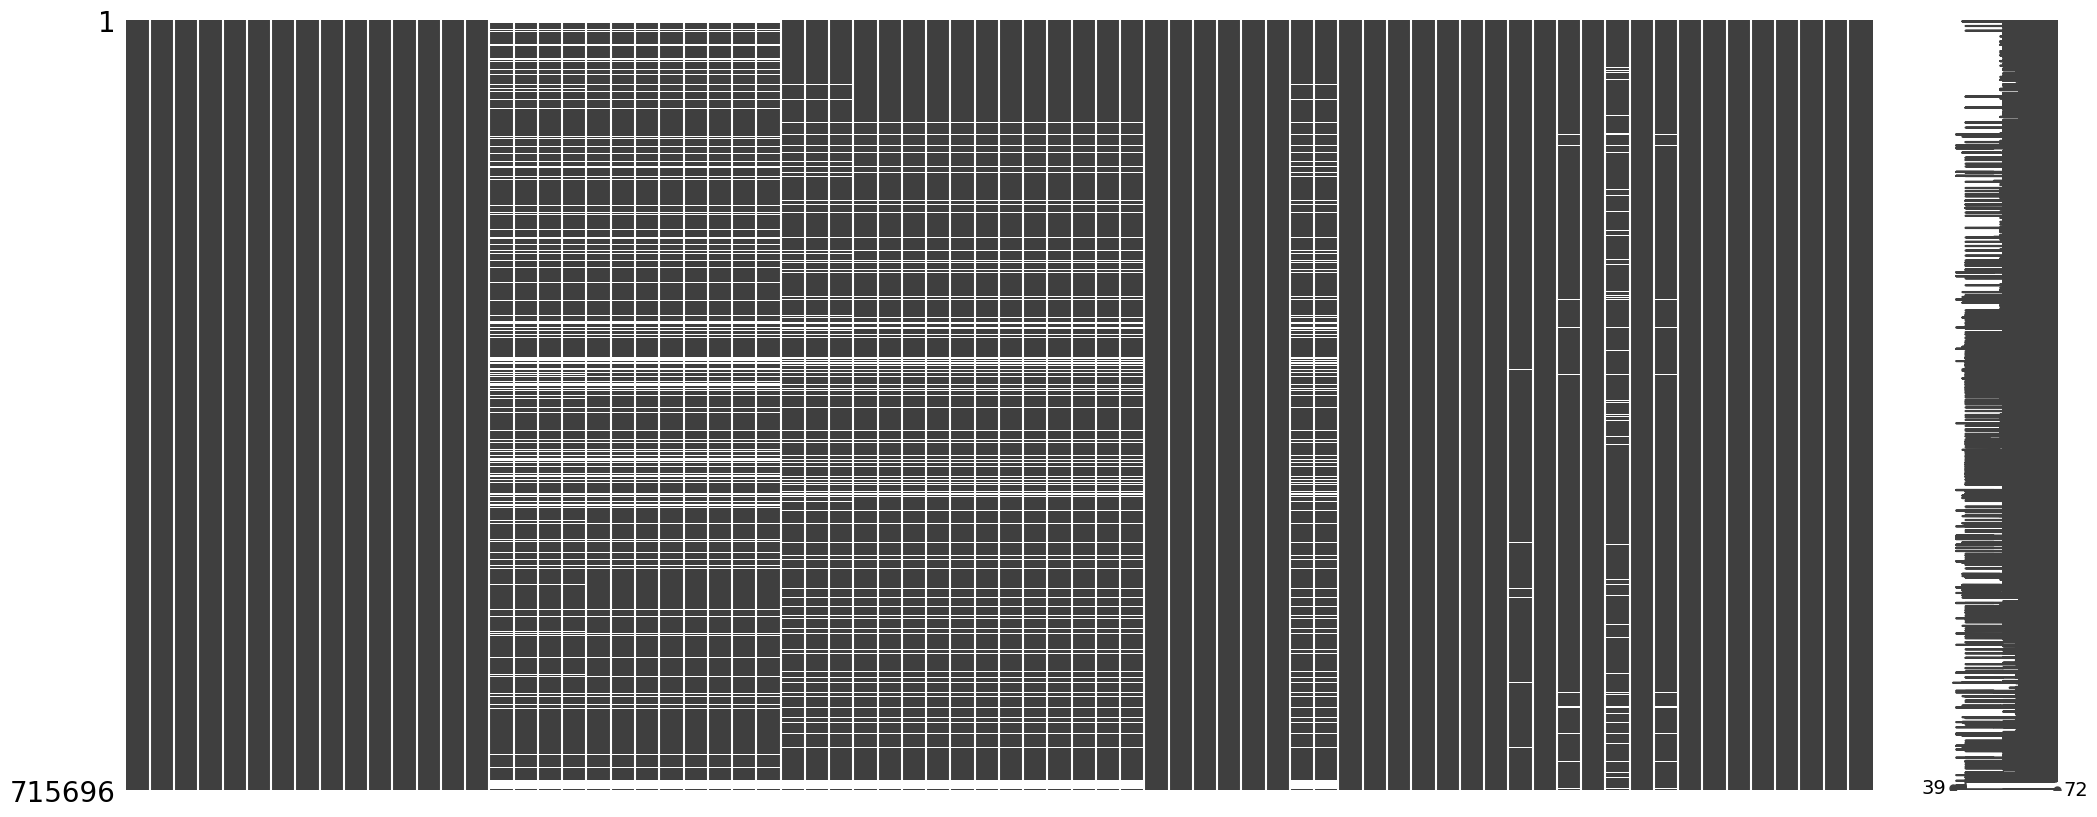

In [68]:
missingno.matrix(merged)

In [69]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

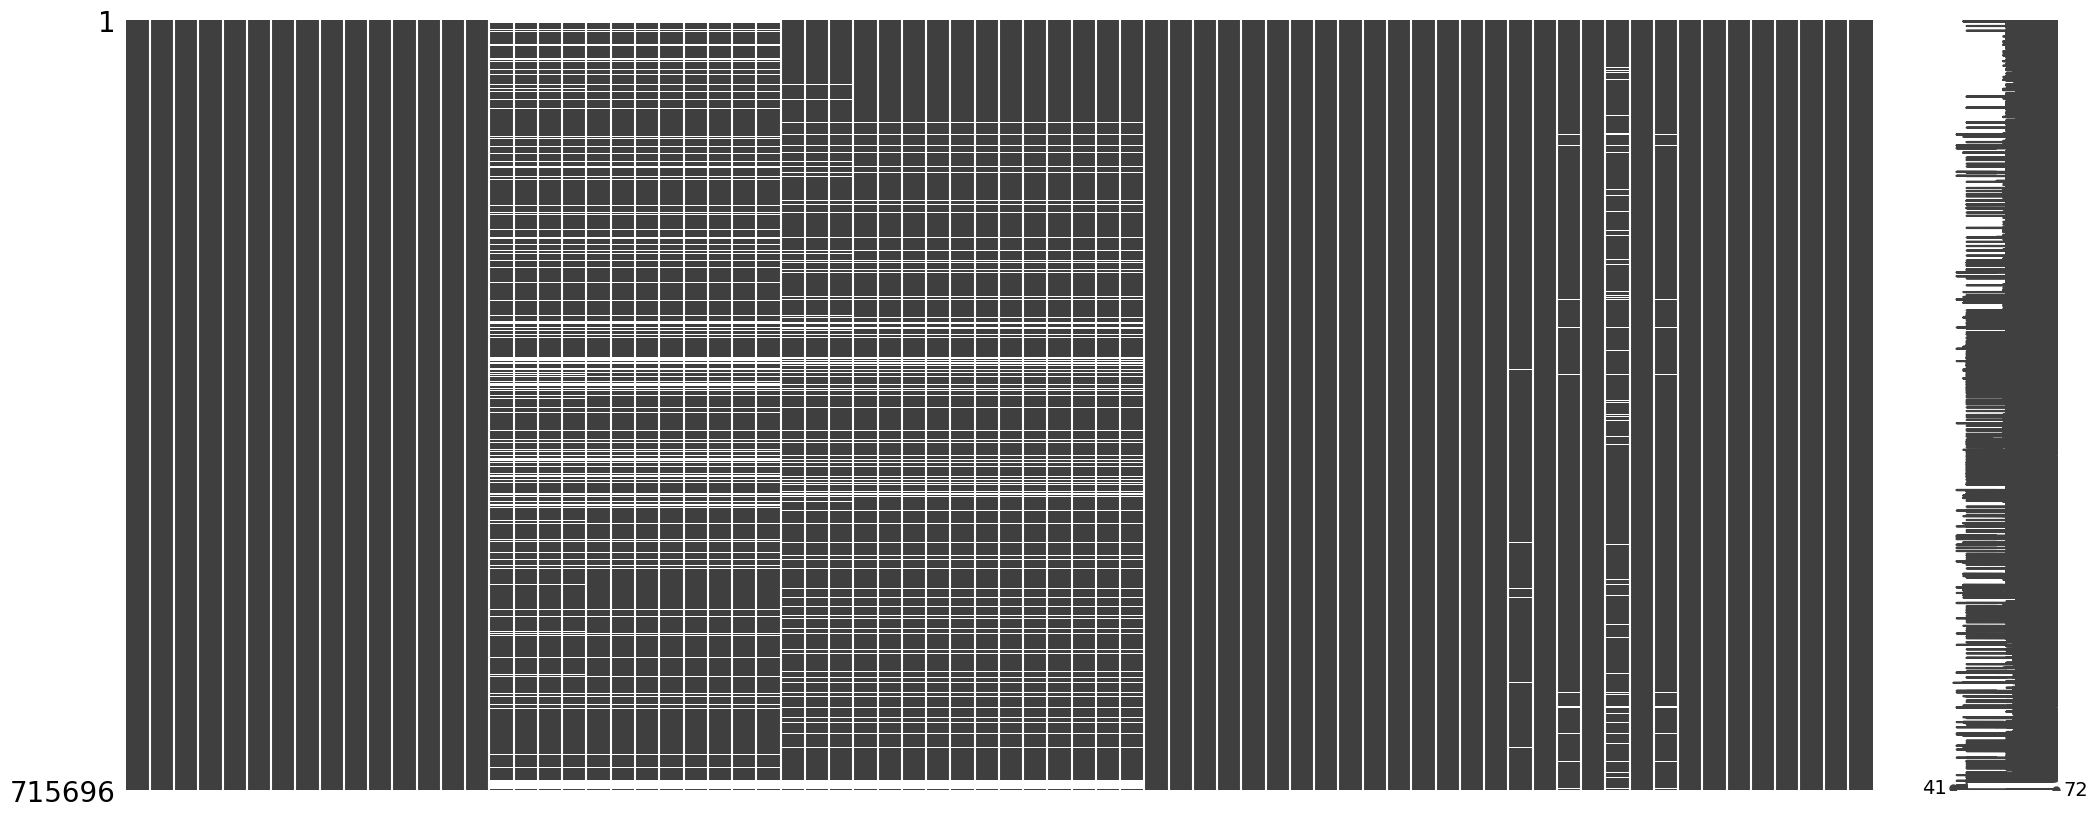

In [70]:
missingno.matrix(merged)

In [71]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022])

In [72]:
cell_codes_un = merged.cell_code.unique()
cell_codes_un

array(['AAE407', 'AAE468', 'AAF412', ..., 'ZC372', 'ZJ376', 'ZV382'],
      dtype=object)

In [73]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_code'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_code': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [74]:
biovars_df.head(20)

,cell_code,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,AAE407,2009,19.250000,18.666667,47.863248,773.275207,42.000000,3.000000,39.000000,10.666667,29.000000,29.000000,10.500000,2145.000000,407.000000,4.000000,80.863945,1070.000000,15.000000,15.000000,943.000000
1,AAE468,2009,16.833333,20.500000,50.000000,796.107957,41.000000,0.000000,41.000000,8.500000,27.333333,27.333333,7.833333,1746.000000,328.000000,0.000000,81.286010,818.000000,1.000000,1.000000,655.000000
2,AAF412,2009,19.458333,20.583333,46.780303,795.000953,44.000000,0.000000,44.000000,10.500000,29.500000,29.500000,10.166667,2145.000000,407.000000,4.000000,80.863945,1070.000000,15.000000,15.000000,943.000000
3,AAF418,2009,18.916667,18.833333,45.934959,773.373170,42.000000,1.000000,41.000000,10.500000,28.666667,28.666667,10.166667,2022.000000,366.000000,2.000000,79.439558,985.000000,14.000000,14.000000,854.000000
4,AAF461,2009,19.416667,20.833333,49.603175,783.591189,42.000000,0.000000,42.000000,11.000000,29.166667,29.166667,9.833333,1825.000000,345.000000,0.000000,81.455549,855.000000,4.000000,4.000000,707.000000
5,AAG451,2009,18.583333,14.166667,41.666667,657.416892,37.000000,3.000000,34.000000,11.500000,26.833333,26.833333,10.500000,1842.000000,329.000000,0.000000,81.593316,892.000000,4.000000,4.000000,712.000000
6,AAH380,2009,17.000000,19.666667,46.825397,786.823302,42.000000,0.000000,42.000000,8.333333,26.666667,26.666667,7.666667,1788.000000,415.000000,0.000000,85.666961,932.000000,4.000000,4.000000,824.000000
7,AAI437,2009,18.083333,20.000000,46.511628,820.984258,42.000000,-1.000000,43.000000,9.000000,28.333333,28.333333,8.833333,1899.000000,345.000000,0.000000,82.798159,929.000000,4.000000,4.000000,752.000000
8,AAK407,2009,16.375000,19.416667,47.357724,853.102626,41.000000,0.000000,41.000000,7.500000,27.166667,27.166667,7.000000,2294.000000,475.000000,9.000000,79.160486,1153.000000,43.000000,43.000000,1054.000000
9,AAK447,2009,18.916667,19.166667,39.930556,824.299519,42.000000,-6.000000,48.000000,9.500000,29.166667,29.166667,9.166667,1889.000000,347.000000,0.000000,82.126698,910.000000,4.000000,4.000000,728.000000


In [75]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_code', 'year'])

In [76]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['cell_code'] == 'AAS419')]

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
3204,AAS419,2010-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.249183,35.284255,2,2,1,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.431935,2.933226,5.182581,7.431935,7.945714,15.953871,19.549333,2.933226,2.219286,4.715806,6.297333,5.182581,5.082500,10.334839,12.923333,13.877258,17.195644,157.429416,430.194987,430.194987,430.194987,-0.690000,13.090000,5268.099411,2664.301041,22,133.836823,1266.184812,161.777864,0.000000,5.774587,31,89.000000,30,89.000000,30,89.000000,10,10,1,6,6,2,0,0,15.958333,20.583333,52.777778,724.712587,37.000000,-2.000000,39.000000,9.666667,24.666667,24.666667,7.166667,1400.000000,430.000000,1.000000,119.347874,908.000000,13.000000,13.000000,906.000000
3205,AAS419,2010-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.249183,35.284255,2,2,1,2010,2,0.176543,-0.085956,-0.253973,0.085956,0.184201,-0.071922,-0.258068,0.071922,0.027260,0.032776,0.020391,0.032776,7.945714,2.219286,5.082500,7.431935,7.945714,15.953871,19.549333,2.933226,2.219286,4.715806,6.297333,5.182581,5.082500,10.334839,12.923333,5.101018,19.681789,66.625909,146.221793,573.023496,142.828509,-2.170000,14.210000,5268.099411,2664.301041,22,133.836823,1266.184812,161.777864,0.000000,5.774587,31,89.000000,30,89.000000,30,89.000000,10,10,1,6,6,2,0,0,15.958333,20.583333,52.777778,724.712587,37.000000,-2.000000,39.000000,9.666667,24.666667,24.666667,7.166667,1400.000000,430.000000,1.000000,119.347874,908.000000,13.000000,13.000000,906.000000
3206,AAS419,2010-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.249183,35.284255,2,2,1,2010,3,0.239395,-0.091942,-0.320011,0.091942,0.254565,-0.064895,-0.313723,0.064895,0.054882,0.058119,0.022091,0.058119,15.953871,4.715806,10.334839,7.431935,7.945714,15.953871,19.549333,2.933226,2.219286,4.715806,6.297333,5.182581,5.082500,10.334839,12.923333,2.545400,5.812107,8.808516,78.077397,651.930892,78.907396,-0.050000,20.150000,5268.099411,2664.301041,22,133.836823,1266.184812,161.777864,0.000000,5.774587,31,89.000000,30,89.000000,30,89.000000,10,10,1,6,6,2,0,0,15.958333,20.583333,52.777778,724.712587,37.000000,-2.000000,39.000000,9.666667,24.666667,24.666667,7.166667,1400.000000,430.000000,1.000000,119.347874,908.000000,13.000000,13.000000,906.000000
3207,AAS419,2010-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.249183,35.284255,2,2,1,2010,4,0.188746,0.120450,-0.058189,-0.120450,0.173501,0.111130,-0.055087,-0.111130,0.020327,0.012427,0.004135,0.012427,19.549333,6.297333,12.923333,7.431935,7.945714,15.953871,19.549333,2.933226,2.219286,4.715806,6.297333,5.182581,5.082500,10.334839,12.923333,1.014122,4.996866,17.406567,30.423651,682.354544,30.423651,1.970000,26.170000,5268.099411,2664.301041,22,133.836823,1266.184812,161.777864,0.000000,5.774587,31,89.000000,30,89.000000,30,89.000000,10,10,1,6,6,2,0,0,15.958333,20.583333,52.777778,724.712587,37.000000,-2.000000,39.000000,9.666667,24.666667,24.666667,7.166667,1400.000000,430.000000,1.000000,119.347874,908.000000,13.000000,13.000000,906.000000
3208,AAS419,2010-05,EL4,

In [77]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [78]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [79]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [80]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [81]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

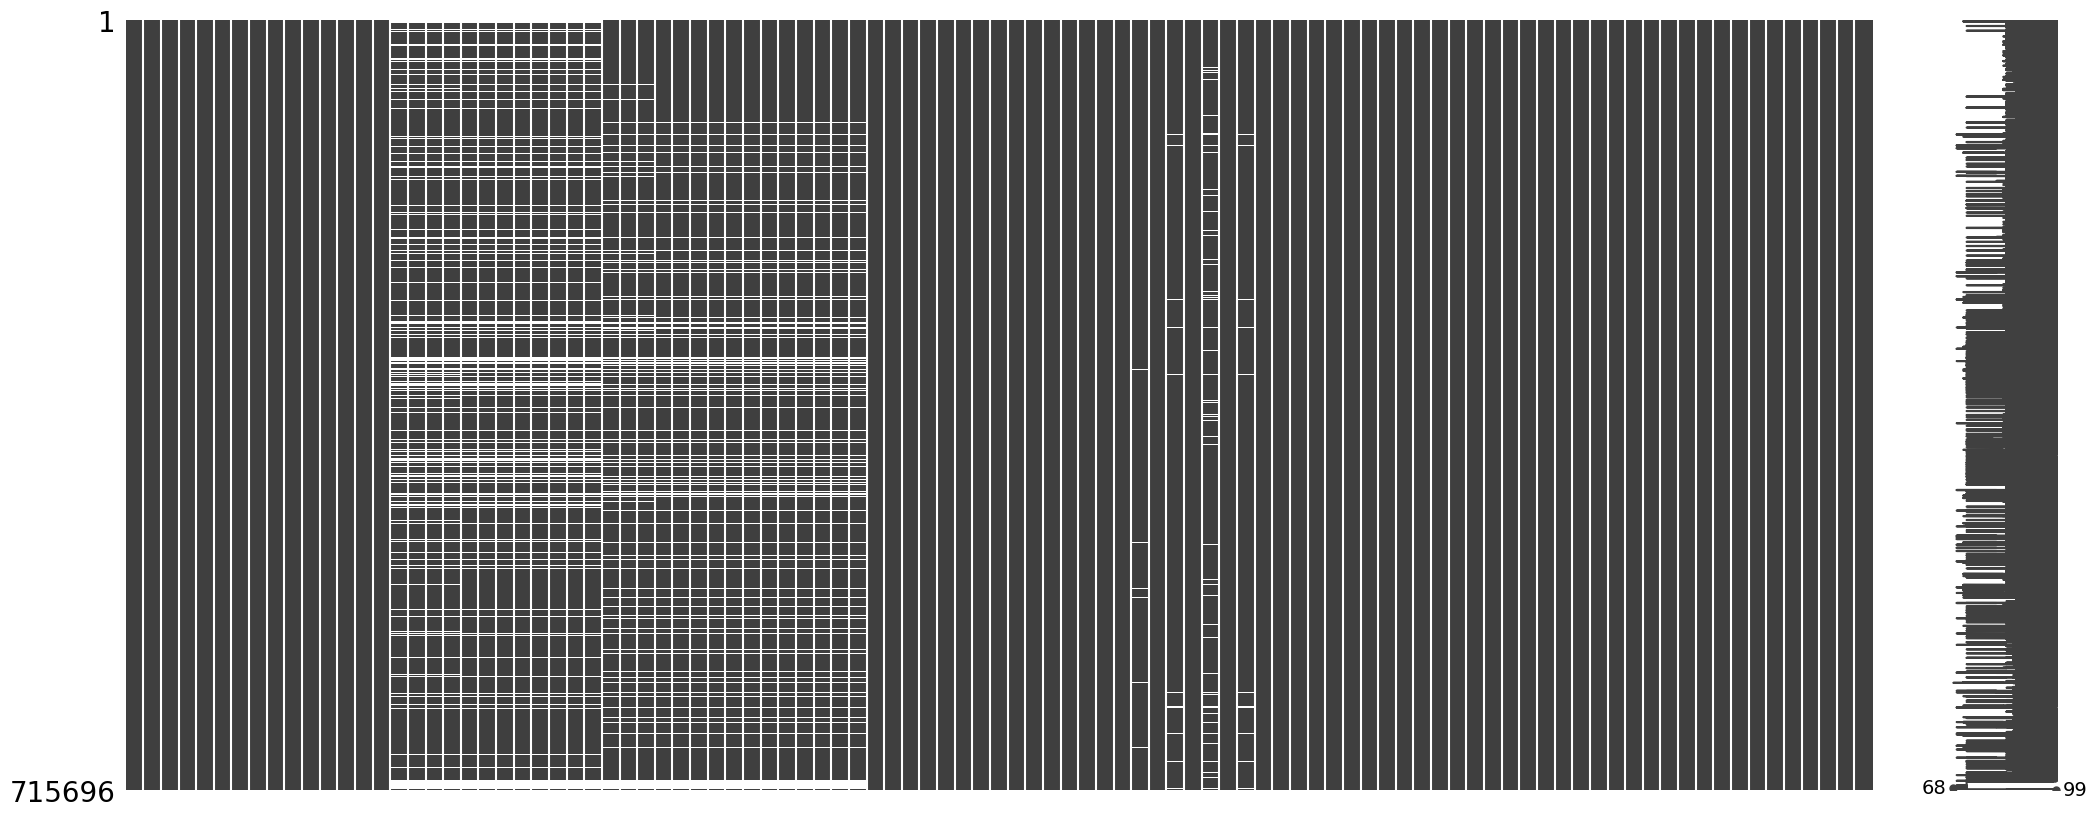

In [82]:
missingno.matrix(dataset)

In [83]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [84]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [85]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [86]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [87]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

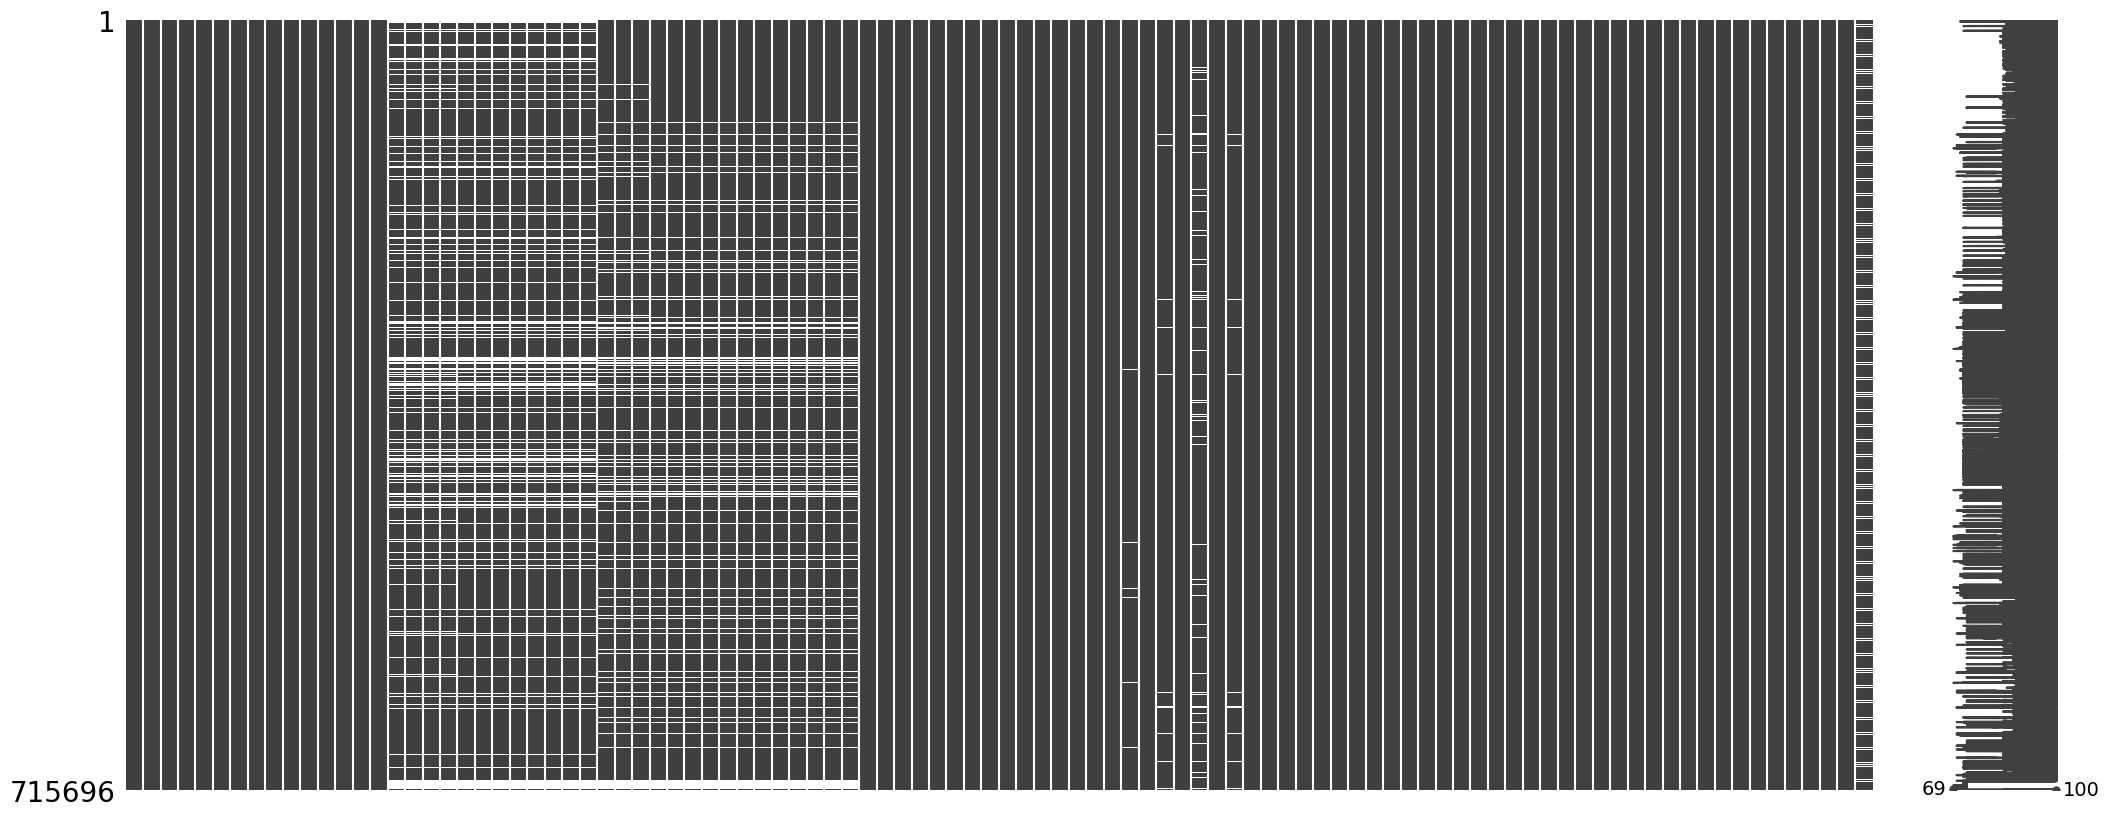

In [88]:
missingno.matrix(dataset)

In [89]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [90]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [91]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [92]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [93]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

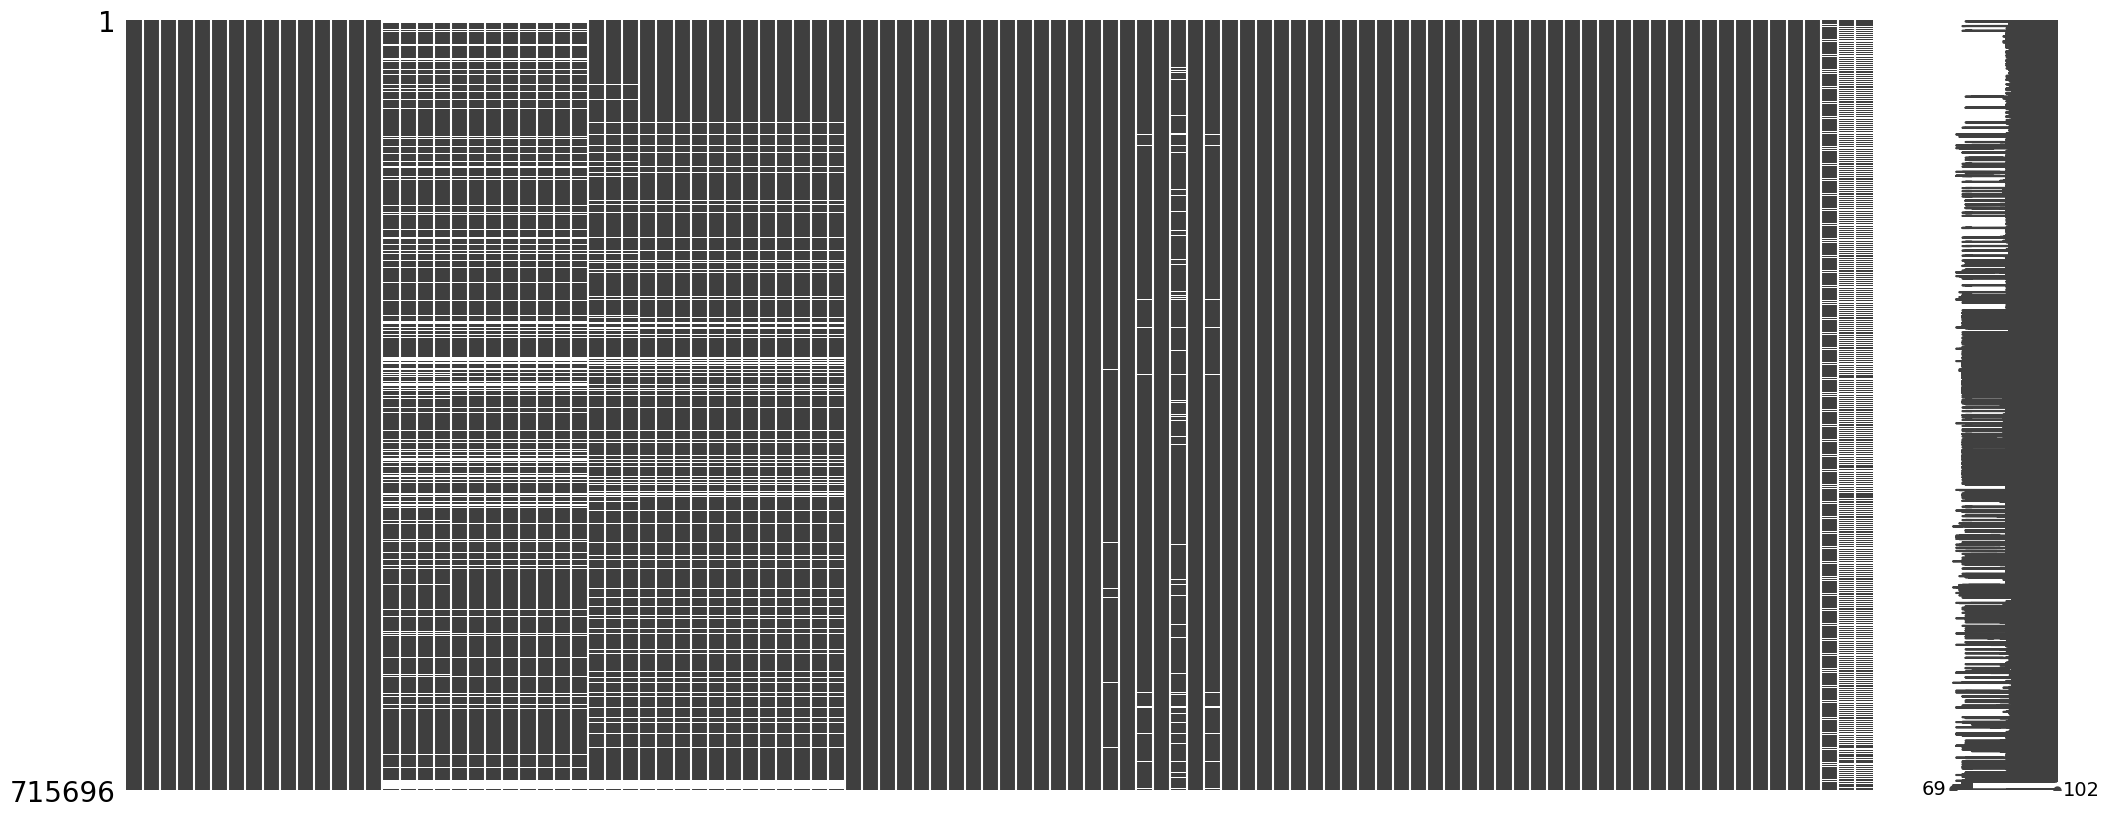

In [94]:
missingno.matrix(dataset)

In [95]:
missing = describe_dataframe(dataset)

In [96]:
missing

,Column,Missing
0,cell_code,0.000000
1,dt_placement,0.000000
2,NUTS1_ID,0.000000
3,NUTS1_NAME,0.000000
4,NUTS2_ID,0.000000
...,...,...
97,F_Y_GE65,0.000000
98,F_TOTAL,0.000000
99,MIO_EUR,14.285500
100,L_TOTAL,48.714500


In [97]:
dataset

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,7.764194,10.811250,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,11.289533,89.988620,121.504665,347.327549,349.975530,349.975530,5.030000,15.310000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.000000,3.000000,39.000000,10.666667,29.000000,29.000000,10.500000,2145.000000,407.000000,4.000000,80.863945,1070.000000,15.000000,15.000000,943.000000,12899.000000,52814.000000,11989.000000,77702.000000,12363.000000,50340.000000,14324.000000,77027.000000,2953.850000,4278.000000,4973.000000
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,10.422857,11.203929,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,14.562216,133.844776,205.302734,422.839291,757.717577,407.742047,3.610000,18.390000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.000000,3.000000,39.000000,10.666667,29.000000,29.000000,10.500000,2145.000000,407.000000,4.000000,80.863945,1070.000000,15.000000,15.000000,943.000000,12899.000000,52814.000000,11989.000000,77702.000000,12363.000000,50340.000000,14324.000000,77027.000000,2953.850000,4278.000000,4973.000000
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,3,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,7.003548,11.445806,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,6.033606,16.994903,36.774120,174.351656,944.759366,187.041788,3.610000,19.090000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.000000,3.000000,39.000000,10.666667,29.000000,29.000000,10.500000,2145.000000,407.000000,4.000000,80.863945,1070.000000,15.000000,15.000000,943.000000,12899.000000,52814.000000,11989.000000,77702.000000,12363.000000,50340.000000,14324.000000,77027.000000,2953.850000,4278.000000,4973.000000
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,4,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,10.883333,16.411333,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.5

In [98]:
dataset.reset_index(inplace=True, drop=True)

In [99]:
dataset['cases'].value_counts()

cases
0    714455
1      1135
2        83
3        17
4         4
6         2
Name: count, dtype: int64

In [100]:
dataset['cases'].sum()

1380

In [101]:
dataset

,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,AAE407,2009-01,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.385833,7.764194,10.811250,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,11.289533,89.988620,121.504665,347.327549,349.975530,349.975530,5.030000,15.310000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.000000,3.000000,39.000000,10.666667,29.000000,29.000000,10.500000,2145.000000,407.000000,4.000000,80.863945,1070.000000,15.000000,15.000000,943.000000,12899.000000,52814.000000,11989.000000,77702.000000,12363.000000,50340.000000,14324.000000,77027.000000,2953.850000,4278.000000,4973.000000
1,AAE407,2009-02,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.985000,10.422857,11.203929,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,14.562216,133.844776,205.302734,422.839291,757.717577,407.742047,3.610000,18.390000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.000000,3.000000,39.000000,10.666667,29.000000,29.000000,10.500000,2145.000000,407.000000,4.000000,80.863945,1070.000000,15.000000,15.000000,943.000000,12899.000000,52814.000000,11989.000000,77702.000000,12363.000000,50340.000000,14324.000000,77027.000000,2953.850000,4278.000000,4973.000000
2,AAE407,2009-03,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,3,0.401553,0.130591,-0.214954,-0.130591,0.411023,0.122728,-0.243686,-0.122728,0.018675,0.028777,0.023867,0.028777,15.888065,7.003548,11.445806,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.575013,11.203929,11.445806,16.411333,6.033606,16.994903,36.774120,174.351656,944.759366,187.041788,3.610000,19.090000,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,22,72.000000,20,72.000000,20,72.000000,9,9,4,1,1,2,0,0,19.250000,18.666667,47.863248,773.275207,42.000000,3.000000,39.000000,10.666667,29.000000,29.000000,10.500000,2145.000000,407.000000,4.000000,80.863945,1070.000000,15.000000,15.000000,943.000000,12899.000000,52814.000000,11989.000000,77702.000000,12363.000000,50340.000000,14324.000000,77027.000000,2953.850000,4278.000000,4973.000000
3,AAE407,2009-04,EL4,"νησια αιγαιου, κρητη",EL43,κρητη,EL434,αποκορωνου,24.117404,35.410691,2,2,1,2009,4,0.385395,0.147468,-0.190282,-0.147468,0.390423,0.140411,-0.216903,-0.140411,0.016822,0.022165,0.019810,0.022165,21.939333,10.883333,16.411333,13.385833,11.985000,15.888065,21.939333,7.764194,10.422857,7.003548,10.883333,10.5

In [102]:
cols = dataset.columns

In [103]:
print(cols)


Index(['cell_code', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'LAU1_NAME', 'x', 'y',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [104]:
len(cols)

102

In [105]:
dataset.to_csv(f"../data/{NUTS0}_WNV_Dataset_GRID_2009_2022.csv", encoding = enc, index = False)
